In [1]:
from pynq import Overlay
from pynq import allocate
from pynq import DefaultIP
import xrfdc
from xrfclk import set_ref_clks
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ol = Overlay('PYNQ_Design_wrapper.bit')
#ol?

## Initialise RFDC LMK and LMX clocks

In [3]:
set_ref_clks(lmk_freq=122.88, lmx_freq=204.8) #LMK04832 LMX2594 lmk_freq=122.88, lmx_freq=204.8

## Set up RF Data Converters
Since were sending data out of the RF DAC and receiveing through the RF ADC, they need to be configured. <br>
Configure RF-ADC channel first.

BTW this is from https://github.com/strath-sdr/rfsoc_qsfp_offload/blob/master/boards/RFSoC4x2/rfsoc_qsfp_offload/drivers/overlay.py

In [4]:
rfdc = ol.usp_rf_data_converter_0

In [5]:
def initialise_adc(tile, block, pll_freq=204.8, fs=1024, fc=0.0):
    """Initialise an ADC tile and block in bypass mode.
    """
    rfdc.adc_tiles[tile].DynamicPLLConfig(1, pll_freq, fs)
    rfdc.adc_tiles[tile].blocks[block].NyquistZone = 1
    rfdc.adc_tiles[tile].blocks[block].MixerSettings = {
            'CoarseMixFreq':  xrfdc.COARSE_MIX_BYPASS,
            'EventSource':    xrfdc.EVNT_SRC_TILE,
            'FineMixerScale': xrfdc.MIXER_SCALE_AUTO,
            'Freq':           fc,
            'MixerMode':      xrfdc.MIXER_MODE_R2C,
            'MixerType':      xrfdc.MIXER_TYPE_FINE,
            'PhaseOffset':    0.0
        }
    #rfdc.adc_tiles[tile].blocks[block].UpdateEvent(xrfdc.EVENT_MIXER)
    rfdc.adc_tiles[tile].SetupFIFO(True)
    
def initialise_dac(tile, block, pll_freq=204.8, fs=1024, fc=0.0):
    """Initialise a DAC tile and block in bypass mode.
        """
    rfdc.dac_tiles[tile].DynamicPLLConfig(1, pll_freq, fs)
    rfdc.dac_tiles[tile].blocks[block].NyquistZone = 1
    rfdc.dac_tiles[tile].blocks[block].MixerSettings = {
            'CoarseMixFreq':  xrfdc.COARSE_MIX_BYPASS,
            'EventSource':    xrfdc.EVNT_SRC_TILE,
            'FineMixerScale': xrfdc.MIXER_SCALE_AUTO,
            'Freq':           fc,
            'MixerMode':      xrfdc.MIXER_MODE_C2R,
            'MixerType':      xrfdc.MIXER_TYPE_FINE,
            'PhaseOffset':    0.0
        }
    #rfdc.dac_tiles[tile].blocks[block].MixerSettings['EventSource'] = xrfdc.EVNT_SRC_IMMEDIATE
    rfdc.dac_tiles[tile].SetupFIFO(True)
    


Configure RF-DAC & RF-ADC channels.

In [6]:
ADC_TILE = 0      # ADC Tile 224
ADC_BLOCK = 0       # ADC Block 0
ADC_SAMPLE_FREQUENCY = 1024  # MSps
ADC_PLL_FREQUENCY    = 204.8  # MHz
ADC_FC = -1228.8 # Centering around middle of sample rate

initialise_adc(tile=ADC_TILE,
              block=ADC_BLOCK,
              pll_freq=ADC_PLL_FREQUENCY,
              fs=ADC_SAMPLE_FREQUENCY,
              fc=ADC_FC)

DAC_TILE = 0       # DAC Tile 228
DAC_BLOCK = 0       # DAC Block 0
DAC_SAMPLE_FREQUENCY = 1024  # MSps
DAC_PLL_FREQUENCY = 204.8   # MHz
DAC_FC = 0.0

initialise_dac(tile=DAC_TILE,
              block=DAC_BLOCK,
              pll_freq=DAC_PLL_FREQUENCY,
              fs=DAC_SAMPLE_FREQUENCY,
              fc=DAC_FC
             )

## Initialise PS-PL Communication

In [7]:
tx_dma = ol.TX.axi_dma_tx

In [8]:
rx_dma = ol.RX.axi_dma_rx

In [9]:
rfdc.dac_tiles[DAC_TILE].blocks[DAC_BLOCK].MixerSettings

{'Freq': 0.0,
 'PhaseOffset': 0.0,
 'EventSource': 2,
 'CoarseMixFreq': 0,
 'MixerMode': 2,
 'FineMixerScale': 0,
 'MixerType': 2}

In [ ]:
t = np.arange(0, 1e-3, 1/2.048e9)

signal_10kHz = np.sin(2*np.pi*10e3*t)
signal_504MHz = np.sin(2*np.pi*504e6*t)
modulated_signal = signal_10kHz*signal_504MHz

In [ ]:
#Plot the signals
plt.figure(figsize=(10, 6))
plt.plot(t[:1000000], modulated_signal[:1000000])
plt.title("Modulated Signal")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()
#plt.savefig("Python_generated_signal.png", dpi=300, bbox_inches="tight")

In [ ]:
num_samples = 10000
dma_buffer = allocate(shape=(4000,),dtype=np.uint32)
output_buffer = allocate(shape=(4000,),dtype=np.uint32)
#np.copyto(dma_buffer, modulated_signal[:4000])

In [9]:
print(tx_dma.sendchannel)
print(rx_dma.recvchannel)

In [10]:
input_buffer = allocate(shape=(4000,), dtype=np.uint16)
output_buffer = allocate(shape=(4000,), dtype=np.int16)

num = 0
for i in range(4000):
    input_buffer[i] = 0
    #input_buffer[i] = i

In [11]:
tx_dma.sendchannel.transfer(input_buffer)

In [12]:
rx_dma.recvchannel.transfer(output_buffer)

In [13]:
tx_dma.sendchannel.wait()

In [14]:
rx_dma.recvchannel.wait()

RuntimeError: DMA channel not started

In [15]:
data=np.array(output_buffer)

In [22]:
def plot_dma_data(data, xlim=None):
    plt.figure(figsize=(10, 5))
    plt.plot(data, label='Received Signal')
    plt.xlabel('Samples')
    plt.ylabel('Magnitude')
    plt.title('Received Signal')
    plt.grid()
    
    if xlim:
        plt.xlim(xlim)
        
    plt.show
    plt.savefig("myplot.png")

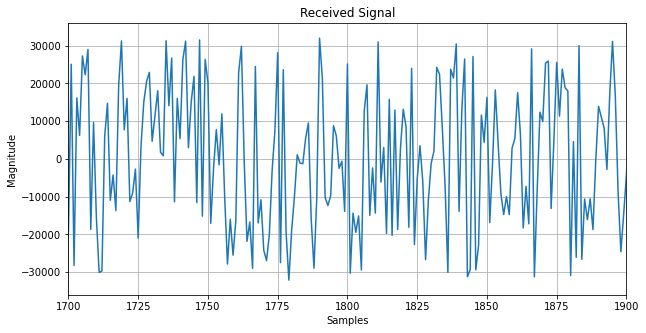

In [26]:
plot_dma_data(output_buffer, xlim=(1700, 1900))

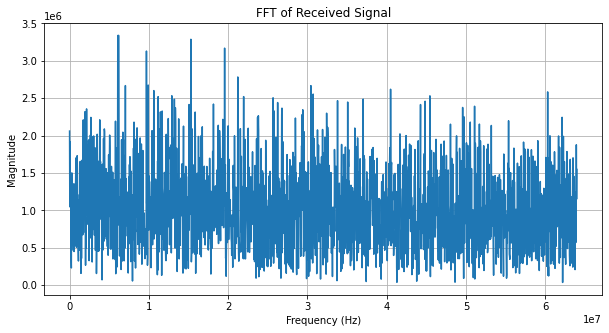

In [ ]:
samp_rate = 128e6

N = len(output_buffer)  # Number of samples

# Compute the FFT
Y = np.fft.fft(output_buffer)  # Compute FFT
frequencies = np.fft.fftfreq(N, d=1/fs)  # Generate frequency axis

# Shift FFT output for two-sided spectrum
Y_shifted = np.fft.fftshift(Y)
frequencies_shifted = np.fft.fftshift(frequencies)

# Plot the magnitude spectrum
plt.figure(figsize=(8, 5))
plt.plot(frequencies_shifted, np.abs(Y_shifted)/N, label="Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Two-Sided FFT of the Signal")
plt.grid()
plt.show()
plt.savefig(RX_FFT.png)
